In [1]:
import tensorflow as tf
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
import hls4ml
from tensorflow.keras.models import load_model
from qkeras.utils import _add_supported_quantized_objects
from hls4ml.model.profiling import numerical
import yaml

2026-07-28 18:50:10.063073: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-28 18:50:10.064055: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-07-28 18:50:10.082138: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-07-28 18:50:10.082653: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-07-28 18:50:10.552652: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:3

In [2]:
data = sio.loadmat('data/sat-6-full.mat')
X_train = data['train_x']
y_train = data['train_y']
X_test = data['test_x']
y_test = data['test_y']

X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

y_train = y_train.astype(np.float32)
y_test = y_test.astype(np.float32)

X_train = np.transpose(X_train, (3, 0, 1, 2))
X_test  = np.transpose(X_test,  (3, 0, 1, 2))

y_train = np.transpose(y_train, (1, 0))
y_test  = np.transpose(y_test,  (1, 0))

In [3]:
co = {}
_add_supported_quantized_objects(co)

q_model = load_model(
    "model_create/results/t1/8bits/best/model.h5",
    custom_objects=co
)

In [4]:
for layer in q_model.layers:
    print(layer.name)

q_conv2d
batch_normalization
q_activation
q_conv2d_1
batch_normalization_1
q_activation_1
flatten
q_dense
batch_normalization_2
q_activation_2
q_dense_1


In [5]:
config_path = "t1_best_8b.yaml"
with open(config_path, "r") as f:
    config = yaml.safe_load(f)
    

hls_model = hls4ml.converters.convert_from_keras_model(
    q_model,
    hls_config=config["HLSConfig"],
    output_dir=config["OutputDir"],
    backend=config["Backend"],
    part=config["Part"],
    clock_period=config["ClockPeriod"],
    io_type=config["IOType"],
    project_name=config["ProjectName"],
)

/home/fauri/Documentos/hls4ml/.venv_hls4ml_t/lib/python3.10/site-packages/hls4ml/backends/fpga/passes/fix_softmax_table_size.py:38: UserWarning: Softmax layer q_dense_1_softmax table size is too large for inputbitwidth 8. Setting table size to 256.To avoid this warning, please increase input bitwidth ordecrease table size.
  warnings.warn(


Profiling weights (before optimization)
Weights for q_dense are only zeros, ignoring.
[{'med': 0.171875, 'q1': 0.0859375, 'q3': 0.28125, 'whislo': 0.0078125, 'whishi': 0.5703125, 'layer': 'q_conv2d', 'weight': 'q_conv2d/w'}, {'med': 0.0078125, 'q1': 0.0078125, 'q3': 0.0078125, 'whislo': 0.0078125, 'whishi': 0.015625, 'layer': 'q_conv2d', 'weight': 'q_conv2d/b'}, {'med': 3.2098575, 'q1': 2.554976463317871, 'q3': 4.299495220184326, 'whislo': 1.3785299, 'whishi': 8.940047, 'layer': 'batch_normalization', 'weight': 'batch_normalization/w'}, {'med': 1.7860901, 'q1': 1.1097763180732727, 'q3': 2.189196467399597, 'whislo': 0.032544564, 'whishi': 2.4114938, 'layer': 'batch_normalization', 'weight': 'batch_normalization/b'}, {'med': 0.1875, 'q1': 0.09375, 'q3': 0.3125, 'whislo': 0.0078125, 'whishi': 0.578125, 'layer': 'q_conv2d_1', 'weight': 'q_conv2d_1/w'}, {'med': 0.0078125, 'q1': 0.0078125, 'q3': 0.0078125, 'whislo': 0.0078125, 'whishi': 0.015625, 'layer': 'q_conv2d_1', 'weight': 'q_conv2d_1/

(<Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>)

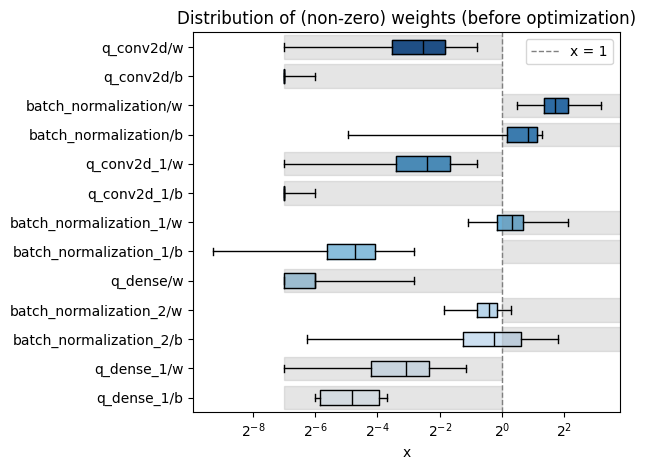

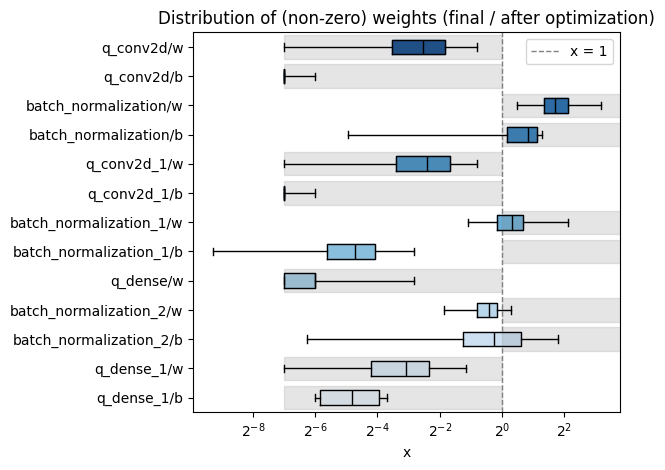

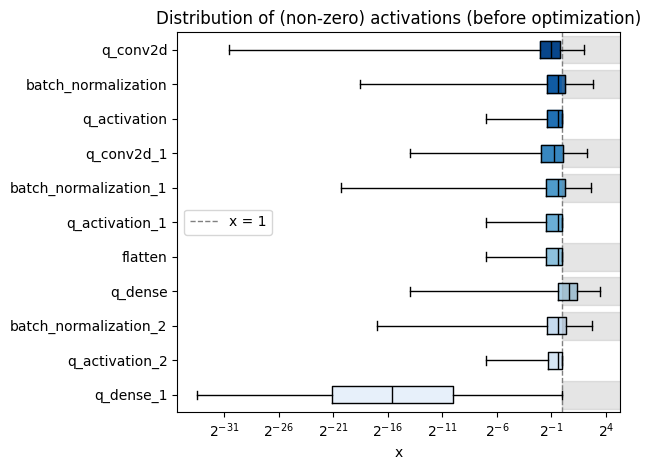

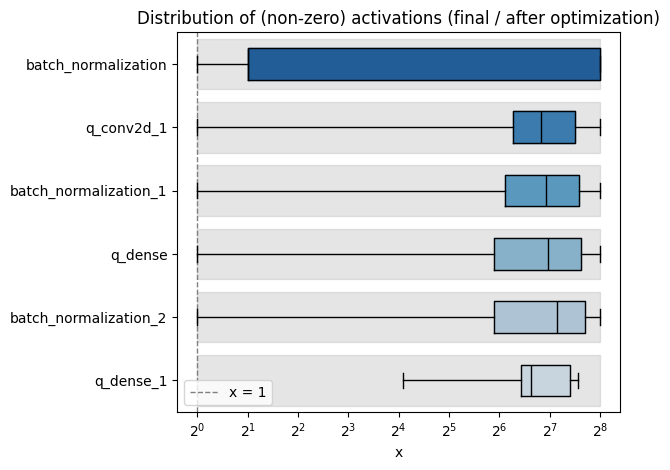

In [6]:
hls4ml.model.profiling.numerical(
    model=q_model,
    hls_model=hls_model,
    X=X_test[:1000]
)

In [7]:
hls_model.write()
hls_model.compile()

In [8]:
hls_model.build(
        csim=True,
        synth=True,
        cosim=True,
        export=True,
    )


****** vitis-run v2024.2 (64-bit)
  **** SW Build 5239630 on 2024-11-10-11:19:46
  **** Start of session at: Tue Jul 28 18:50:55 2026
    ** Copyright 1986-2022 Xilinx, Inc. All Rights Reserved.
    ** Copyright 2022-2024 Advanced Micro Devices, Inc. All Rights Reserved.

  **** HLS Build v2024.2 5238294
Sourcing Tcl script '/home/fauri/Documentos/hls4ml/project/outputs/t1_best_8b/build_prj.tcl'
INFO: [HLS 200-1510] Running: open_project t1_best_8b_prj 
INFO: [HLS 200-10] Opening project '/home/fauri/Documentos/hls4ml/project/outputs/t1_best_8b/t1_best_8b_prj'.
INFO: [HLS 200-1510] Running: set_top t1_best_8b 
INFO: [HLS 200-1510] Running: add_files firmware/t1_best_8b.cpp -cflags -std=c++0x 
INFO: [HLS 200-10] Adding design file 'firmware/t1_best_8b.cpp' to the project
INFO: [HLS 200-1510] Running: add_files -tb t1_best_8b_test.cpp -cflags -std=c++0x 
INFO: [HLS 200-10] Adding test bench file 't1_best_8b_test.cpp' to the project
INFO: [HLS 200-1510] Running: add_files -tb firmware/we

KeyboardInterrupt: 